In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df =pd.read_csv("../Data/Cleaned/Case 2 Dataset.csv")

In [2]:
print("DISTRIBUSI DASAR")
print(f"Total tweet: {len(df)}")
print(f"Unique user: {df['username'].nunique()}")
print(f"Verified user: {df['verified'].sum()}")
print(f"Quote tweet: {df['is_quote'].sum()}")

DISTRIBUSI DASAR
Total tweet: 15000
Unique user: 10479
Verified user: 992
Quote tweet: 2182


In [3]:
print(f"\nRentang waktu:")
df['created_at_dt'] = pd.to_datetime(df['created_at'], format='%a %b %d %H:%M:%S +0000 %Y')
print(f"  Mulai : {df['created_at_dt'].min()}")
print(f"  Akhir : {df['created_at_dt'].max()}")


Rentang waktu:
  Mulai : 2025-01-01 00:47:55
  Akhir : 2025-12-30 23:02:35


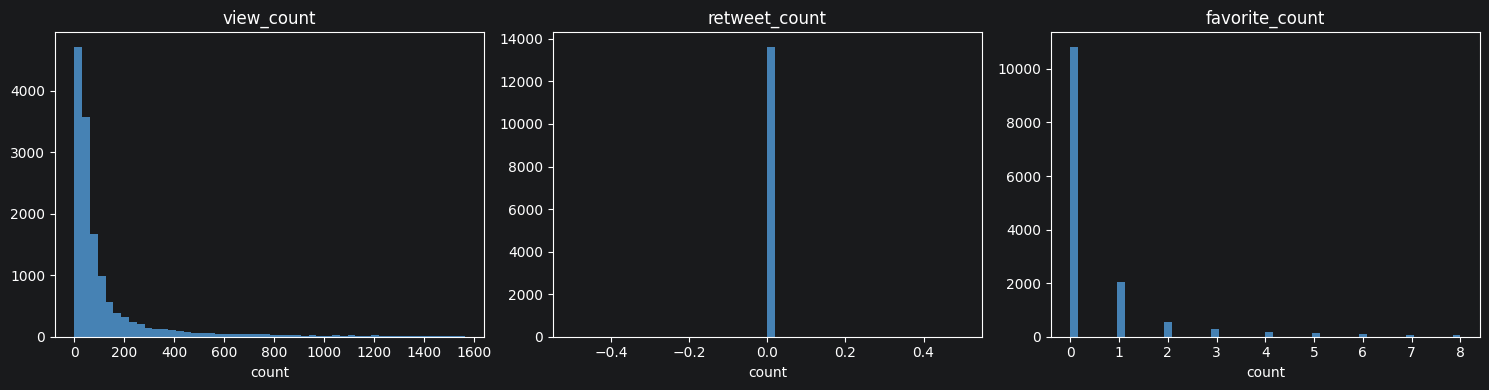

In [4]:
# Distribusi engagement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['view_count', 'retweet_count', 'favorite_count']):
    data = df[col][df[col] < df[col].quantile(0.95)]  # buang outlier ekstrem
    ax.hist(data, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('count')
plt.tight_layout()
plt.show()

In [5]:
# Top 10 source device
print("\nTop 10 source:")
print(df['source'].value_counts().head(10))


Top 10 source:
source
Twitter for Android    9789
Twitter Web App        2621
Twitter for iPhone     1875
Banners & Ads           126
IFTTT                    80
Buffer                   78
cms_socmed_detik         54
Twitter for iPad         52
TweetDeck Web App        43
Ask Grok                 41
Name: count, dtype: int64


In [6]:
# Panjang teks
df['text_len'] = df['clean_text'].str.len()
df['word_count'] = df['clean_text'].str.split().str.len()

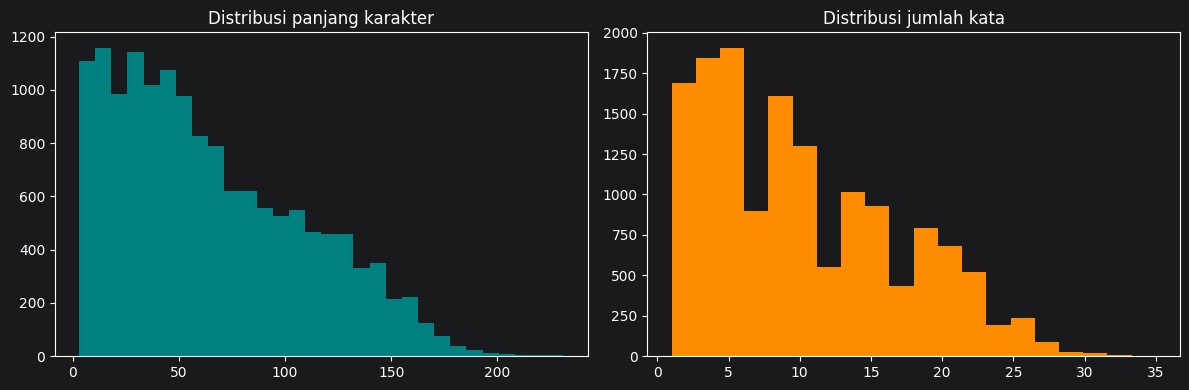

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['text_len'].dropna(), bins=30, color='teal', edgecolor='none')
axes[0].set_title('Distribusi panjang karakter')
axes[1].hist(df['word_count'].dropna(), bins=20, color='darkorange', edgecolor='none')
axes[1].set_title('Distribusi jumlah kata')
plt.tight_layout()
plt.show()

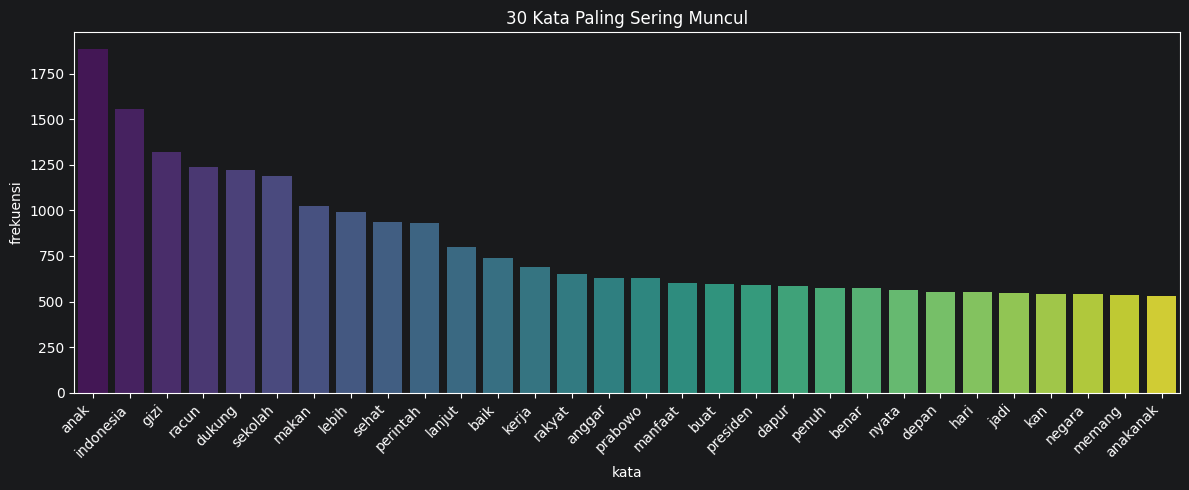

In [8]:
# Most frequent words
from collections import Counter
all_words = " ".join(df['clean_text'].dropna()).split()
word_freq = Counter(all_words)

top30 = pd.DataFrame(word_freq.most_common(30), columns=['kata', 'frekuensi'])
plt.figure(figsize=(12, 5))
sns.barplot(data=top30, x='kata', y='frekuensi', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('30 Kata Paling Sering Muncul')
plt.tight_layout()
plt.show()

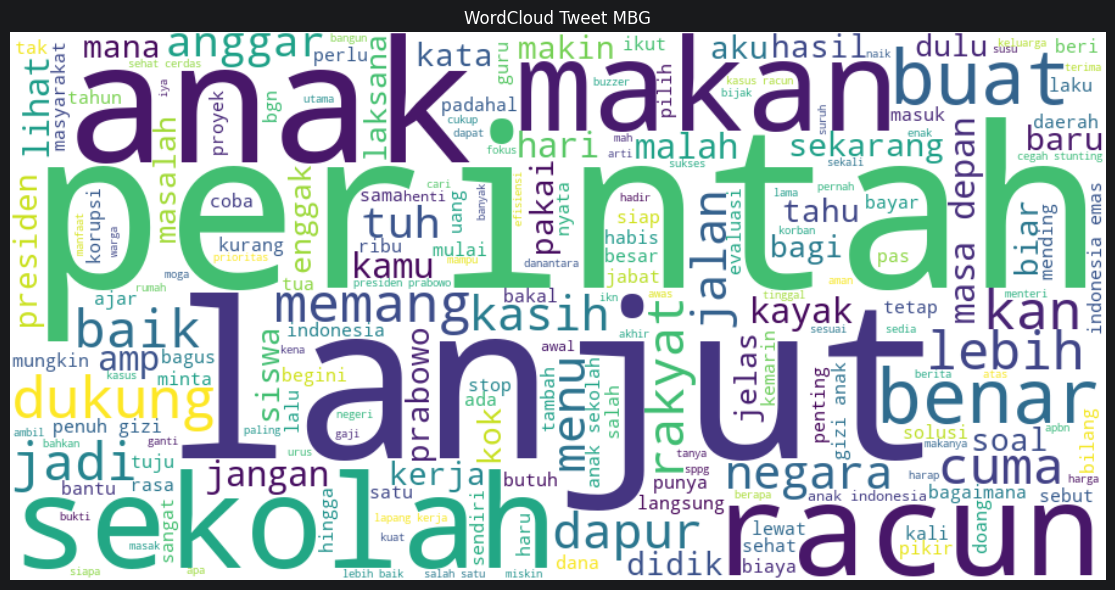

In [9]:
from wordcloud import WordCloud
from nltk.util import ngrams

# WordCloud
text_corpus = " ".join(df['clean_text'].dropna())
wc = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text_corpus)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Tweet MBG')
plt.tight_layout()
plt.show()

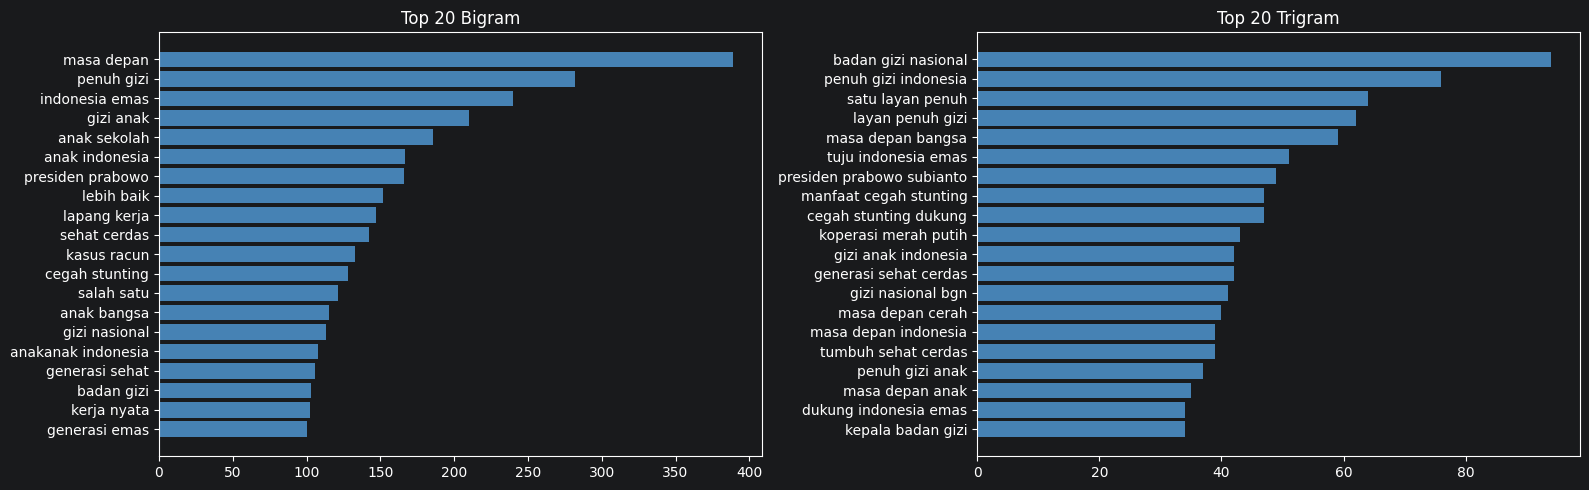

In [10]:
# N-grams (bigram & trigram)
def get_ngrams(corpus, n, top_k=20):
    tokens = corpus.split()
    ng = list(ngrams(tokens, n))
    return Counter(ng).most_common(top_k)

bigrams  = get_ngrams(text_corpus, 2)
trigrams = get_ngrams(text_corpus, 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ng, title in zip(axes, [bigrams, trigrams], ['Top 20 Bigram', 'Top 20 Trigram']):
    labels = [' '.join(g) for g, _ in ng]
    counts = [c for _, c in ng]
    ax.barh(labels[::-1], counts[::-1], color='steelblue')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [11]:
# Cek tweet yang hasilnya kosong setelah cleaning
empty_after_clean = df[df['clean_text'].str.strip() == '']
print(f"Tweet jadi kosong setelah cleaning: {len(empty_after_clean)}")
display(empty_after_clean[['full_text', 'clean_text']].head(10))

# Cek kata super pendek yang lolos (< 2 karakter)
noise_words = [w for w in word_freq if len(w) <= 2]
print(f"\nKata <= 2 karakter yang masih lolos ({len(noise_words)} kata):")
print(sorted(noise_words))

# Cek kata yang frekuensinya cuma 1x (kemungkinan typo/noise)
hapax = [w for w, c in word_freq.items() if c == 1]
print(f"\nHapax legomena (muncul cuma 1x): {len(hapax)} kata")
print(hapax[:10133])

Tweet jadi kosong setelah cleaning: 0


,full_text,clean_text



Kata <= 2 karakter yang masih lolos (0 kata):
[]

Hapax legomena (muncul cuma 1x): 0 kata
[]


In [12]:
df['created_at_dt'] = pd.to_datetime(df['created_at'], format='mixed', utc=True, errors='coerce')

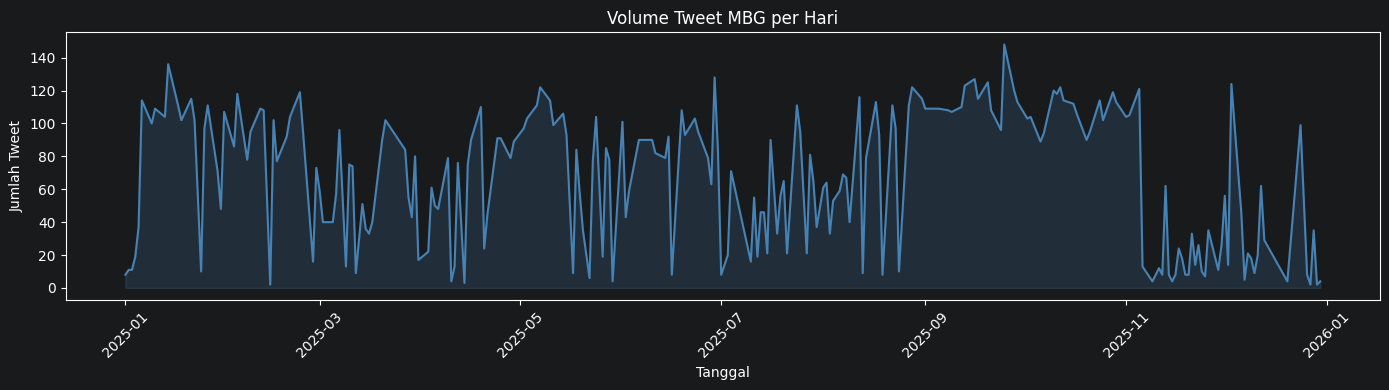

In [13]:
# Pastiin kolom datetime udah ada dari Fase 1
df['date_only'] = df['created_at_dt'].dt.date
df['hour'] = df['created_at_dt'].dt.hour
df['day_of_week'] = df['created_at_dt'].dt.day_name()

# Volume tweet per hari
daily = df.groupby('date_only').size().reset_index(name='tweet_count')
plt.figure(figsize=(14, 4))
plt.plot(daily['date_only'], daily['tweet_count'], color='steelblue', linewidth=1.5)
plt.fill_between(daily['date_only'], daily['tweet_count'], alpha=0.2, color='steelblue')
plt.title('Volume Tweet MBG per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

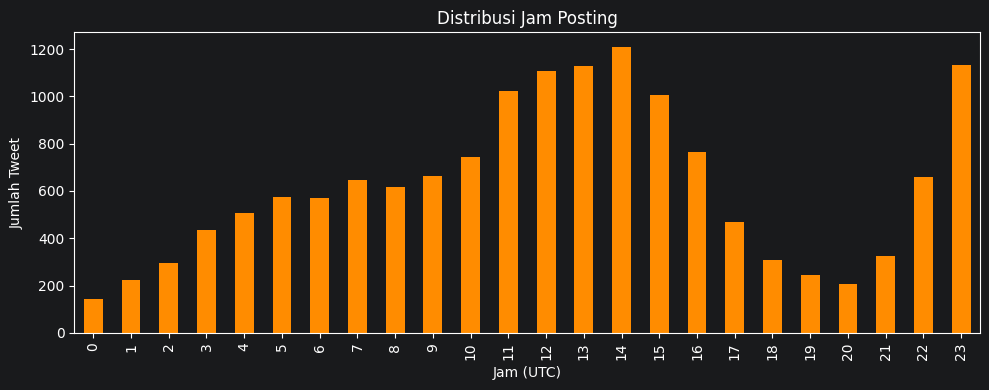

In [14]:
# Distribusi jam posting
plt.figure(figsize=(10, 4))
df['hour'].value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='none')
plt.title('Distribusi Jam Posting')
plt.xlabel('Jam (UTC)')
plt.ylabel('Jumlah Tweet')
plt.tight_layout()
plt.show()

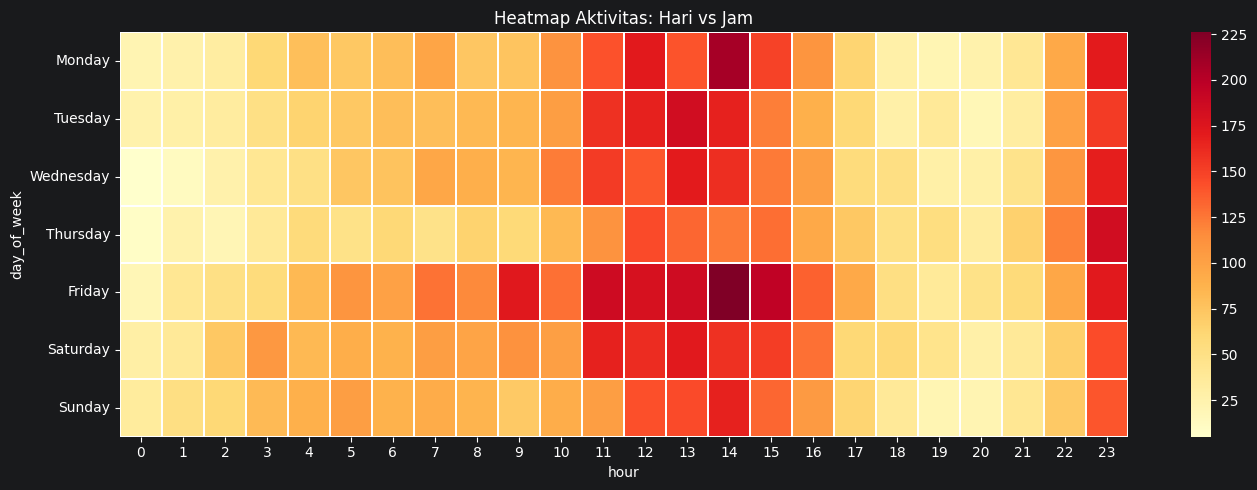

In [15]:
# Heatmap hari vs jam
pivot = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex([d for d in order if d in pivot.index])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white')
plt.title('Heatmap Aktivitas: Hari vs Jam')
plt.tight_layout()
plt.show()